In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Lung_Opacity.metadata.xlsx
/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal.metadata.xlsx
/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/README.md.txt
/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID.metadata.xlsx
/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia.metadata.xlsx
/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images/Normal-859.png
/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images/Normal-158.png
/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images/Normal-10121.png
/kaggle/input/datasets/tawsifur

In [2]:
!git clone https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git

Cloning into 'Chest-X-ray-Disease-Detection'...
remote: Enumerating objects: 433, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 433 (delta 54), reused 61 (delta 38), pack-reused 312 (from 1)
Receiving objects: 100% (433/433), 4.92 MiB | 17.37 MiB/s, done.
Resolving deltas: 100% (190/190), done.


In [3]:
!ls

Chest-X-ray-Disease-Detection  __notebook__.ipynb


In [4]:
!pip install -q -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [5]:
!pip install -q opencv-python-headless albumentations

In [6]:
import torch
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch: 2.10.0+cu128
GPU available: True


In [7]:
from pathlib import Path

for p in Path("/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database").iterdir():
    print(p)

/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset


In [8]:
for root, dirs, files in os.walk("/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database"):
    level = root.replace("/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:
        for f in files[:10]:
            print(f"{indent}  {f}")

covid19-radiography-database/
  COVID-19_Radiography_Dataset/
    Lung_Opacity.metadata.xlsx
    Normal.metadata.xlsx
    README.md.txt
    COVID.metadata.xlsx
    Viral Pneumonia.metadata.xlsx
    Normal/
      images/
      masks/
    Lung_Opacity/
      images/
      masks/
    Viral Pneumonia/
      images/
      masks/
    COVID/
      images/
      masks/


In [9]:
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database")

image_extensions = {".png", ".jpg", ".jpeg"}

images = []

for p in DATA_ROOT.rglob("*"):
    if p.suffix.lower() in image_extensions:
        images.append(p)

print("Total image files:", len(images))

Total image files: 42330


In [10]:
for p in images[:30]:
    print(p)

/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images/Normal-859.png
/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images/Normal-158.png
/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images/Normal-10121.png
/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images/Normal-1811.png
/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images/Normal-97.png
/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images/Normal-1088.png
/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images/Normal-5663.png
/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images/Normal-6328

In [11]:
xray_images = []
mask_images = []

for p in images:
    name = p.name.lower()

    if "mask" in name:
        mask_images.append(p)
    else:
        xray_images.append(p)

print("X-rays:", len(xray_images))
print("Masks:", len(mask_images))

X-rays: 42330
Masks: 0


In [12]:
xray_images = []
mask_images = []

for p in images:
    if p.parent.name.lower() == "masks":
        mask_images.append(p)
    elif p.parent.name.lower() == "images":
        xray_images.append(p)

print("X-rays:", len(xray_images))
print("Masks:", len(mask_images))

X-rays: 21165
Masks: 21165


In [13]:
def find_mask_for_image(image_path: Path) -> Path | None:
    mask_path = image_path.parent.parent / "masks" / image_path.name
    return mask_path if mask_path.exists() else None

pairs = []
for image_path in xray_images:
    mask_path = find_mask_for_image(image_path)
    pairs.append({
        "image_id": image_path.stem,
        "image_path": str(image_path),
        "mask_path": str(mask_path) if mask_path else None,
    })

pairs_df = pd.DataFrame(pairs)
print("With masks:", pairs_df["mask_path"].notna().sum())
print("Without masks:", pairs_df["mask_path"].isna().sum())

With masks: 21165
Without masks: 0


In [14]:
# --- Dimension check ---
dimension_records = []

for _, row in pairs_df.dropna(subset=["mask_path"]).iterrows():
    image = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

    dimension_records.append({
        "image_id": row["image_id"],
        "image_shape": None if image is None else image.shape,
        "mask_shape": None if mask is None else mask.shape,
        "same_shape": (
            image is not None and
            mask is not None and
            image.shape == mask.shape
        )
    })

dimension_df = pd.DataFrame(dimension_records)
print(dimension_df["same_shape"].value_counts(dropna=False))

# --- Mask quality: empty / full / corrupt ---
mask_quality = []

for _, row in pairs_df.dropna(subset=["mask_path"]).iterrows():
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

    if mask is None:
        mask_quality.append({
            "image_id": row["image_id"], "valid_read": False,
            "coverage": np.nan, "empty": None, "full": None,
        })
        continue

    binary = mask > 127
    coverage = float(binary.mean())

    mask_quality.append({
        "image_id": row["image_id"],
        "valid_read": True,
        "coverage": coverage,
        "empty": bool(binary.sum() == 0),
        "full": bool(binary.sum() == binary.size),
    })

mask_quality_df = pd.DataFrame(mask_quality)
print(mask_quality_df["empty"].value_counts(dropna=False))
print(mask_quality_df["full"].value_counts(dropna=False))
print(mask_quality_df["coverage"].describe())

same_shape
False    21165
Name: count, dtype: int64
empty
False    21165
Name: count, dtype: int64
full
False    21165
Name: count, dtype: int64
count    21165.000000
mean         0.239156
std          0.061974
min          0.029007
25%          0.196075
50%          0.235382
75%          0.277771
max          0.580261
Name: coverage, dtype: float64


In [15]:
sample = dimension_df.sample(5, random_state=42)
print(sample[["image_id", "image_shape", "mask_shape"]])

# Are the shapes at least *consistent* (same mismatch every time)?
print(dimension_df["image_shape"].value_counts())
print(dimension_df["mask_shape"].value_counts())

                image_id image_shape  mask_shape
21113         COVID-1023  (299, 299)  (256, 256)
10611  Lung_Opacity-2198  (299, 299)  (256, 256)
2127         Normal-3389  (299, 299)  (256, 256)
14366  Lung_Opacity-1845  (299, 299)  (256, 256)
12463  Lung_Opacity-3083  (299, 299)  (256, 256)
image_shape
(299, 299)    21165
Name: count, dtype: int64
mask_shape
(256, 256)    21165
Name: count, dtype: int64


label
Normal             10192
Lung_Opacity        6012
COVID               3616
Viral Pneumonia     1345
Name: count, dtype: int64
Normal - Normal-2288


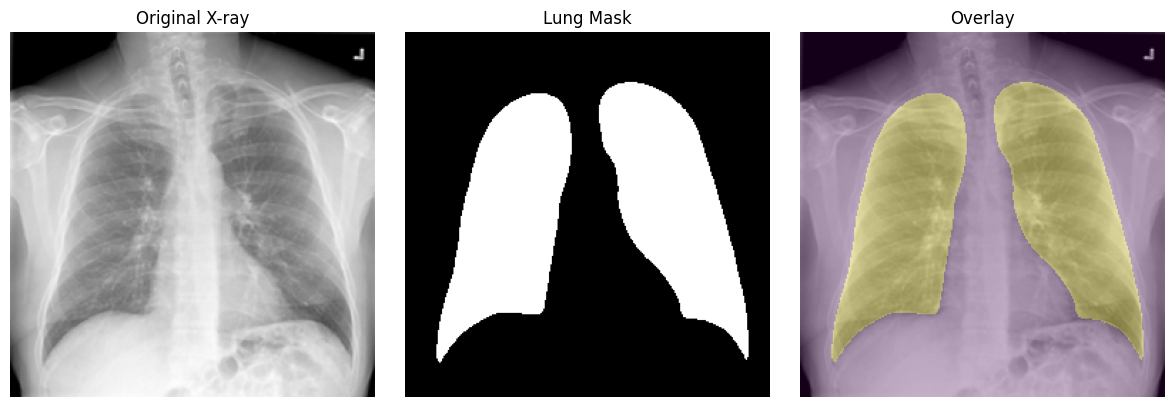

Lung_Opacity - Lung_Opacity-5973


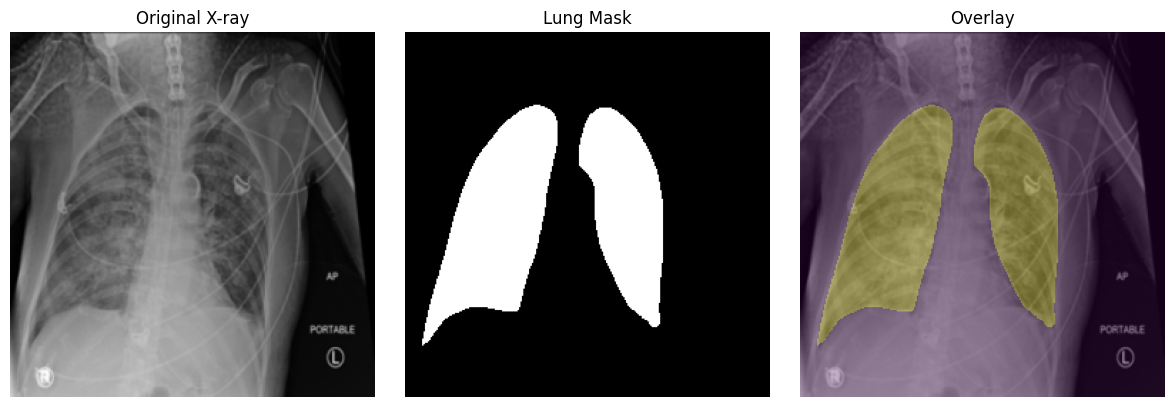

Viral Pneumonia - Viral Pneumonia-320


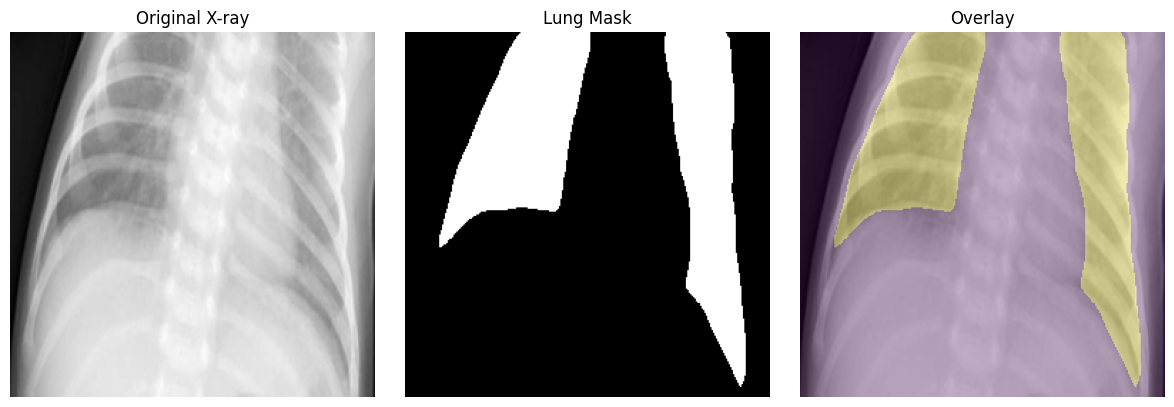

COVID - COVID-201


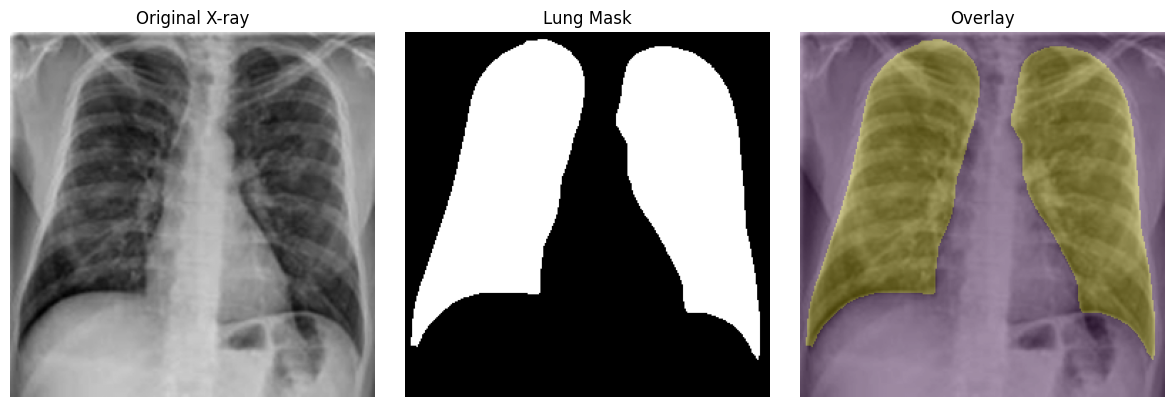

In [16]:
def show_pair(image_path, mask_path, size=256):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    image = cv2.resize(image, (size, size), interpolation=cv2.INTER_AREA)
    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
    binary = mask > 127

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(image, cmap="gray"); plt.title("Original X-ray"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(binary, cmap="gray"); plt.title("Lung Mask"); plt.axis("off")
    plt.subplot(1, 3, 3); plt.imshow(image, cmap="gray"); plt.imshow(binary, alpha=0.30); plt.title("Overlay"); plt.axis("off")
    plt.tight_layout()
    plt.show()

# Label = the class folder name itself, e.g. .../COVID/images/COVID-1023.png -> "COVID"
pairs_with_masks = pairs_df.dropna(subset=["mask_path"]).copy()
pairs_with_masks["label"] = pairs_with_masks["image_path"].apply(lambda p: Path(p).parts[-3])

print(pairs_with_masks["label"].value_counts())

for label in pairs_with_masks["label"].unique():
    subset = pairs_with_masks[pairs_with_masks["label"] == label]
    row = subset.sample(1, random_state=42).iloc[0]
    print(label, "-", row["image_id"])
    show_pair(row["image_path"], row["mask_path"])

Viral Pneumonia-596


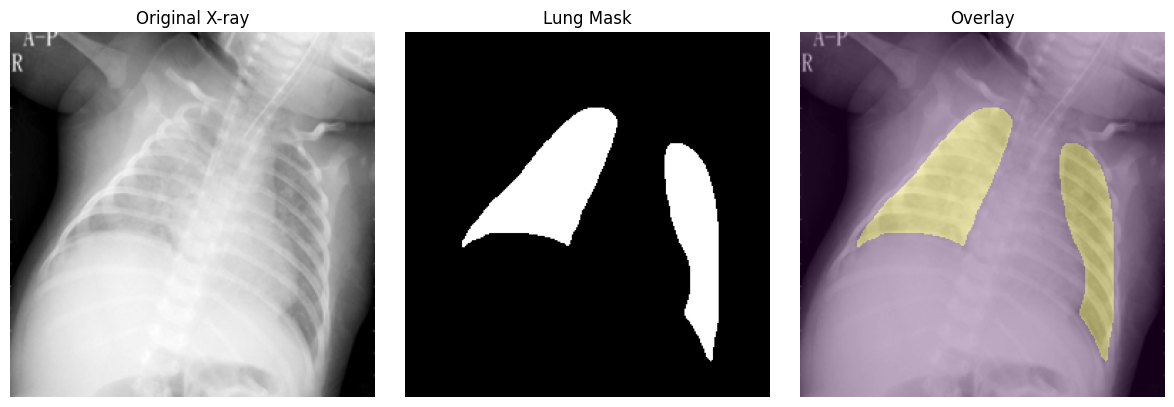

Viral Pneumonia-228


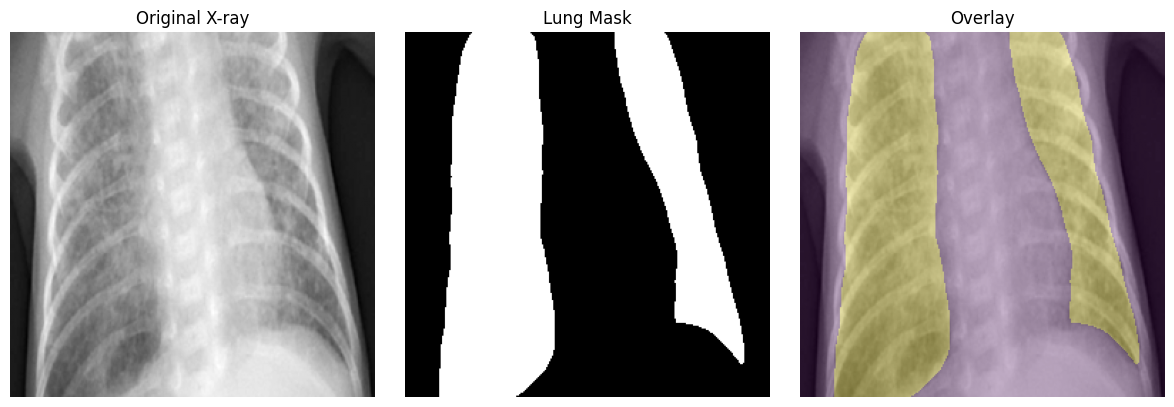

Viral Pneumonia-244


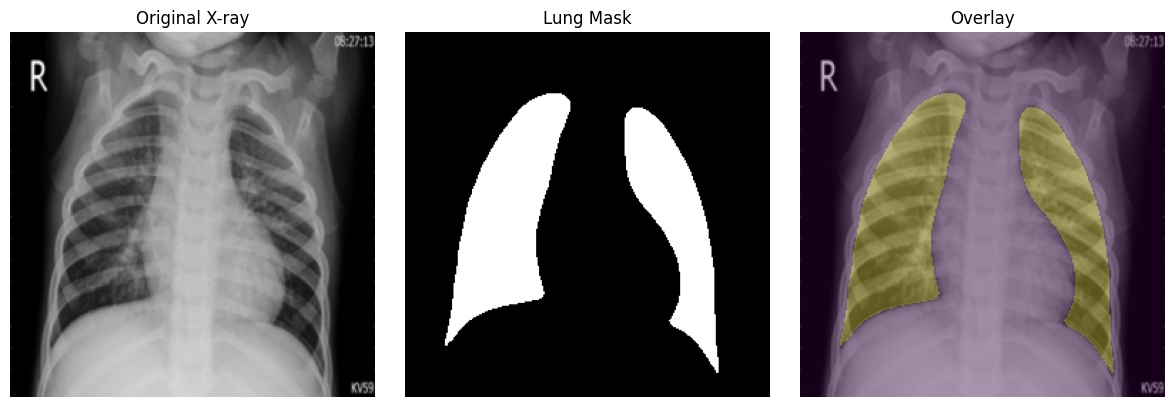

Viral Pneumonia-368


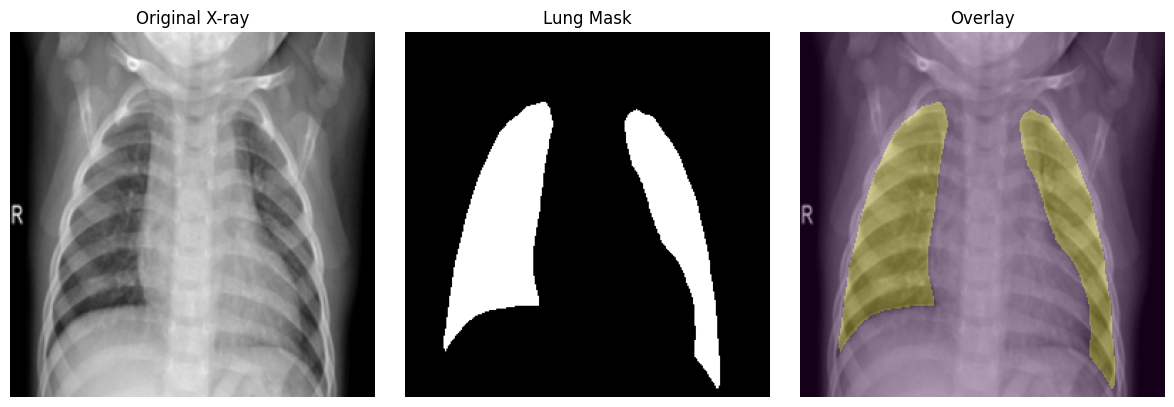

In [17]:
subset = pairs_with_masks[pairs_with_masks["label"] == "Viral Pneumonia"]
for _, row in subset.sample(4, random_state=7).iterrows():
    print(row["image_id"])
    show_pair(row["image_path"], row["mask_path"])

In [18]:
CLASS_MAP = {
    "COVID": 0,
    "Normal": 1,
    "Lung_Opacity": 2,
    "Viral Pneumonia": 3,
}

manifest = pairs_with_masks.copy()  # from your visual-check cell — already has image_id, image_path, mask_path, label
manifest["class_id"] = manifest["label"].map(CLASS_MAP)
manifest["dataset"] = "COVID19_Radiography_Database"

print(manifest["label"].value_counts())
print(manifest["class_id"].value_counts(dropna=False))  # zero NaN expected — if not, a label string doesn't match CLASS_MAP exactly

manifest.to_csv("/kaggle/working/dataset_manifest_v1.csv", index=False)
manifest.head()

label
Normal             10192
Lung_Opacity        6012
COVID               3616
Viral Pneumonia     1345
Name: count, dtype: int64
class_id
1    10192
2     6012
0     3616
3     1345
Name: count, dtype: int64


,image_id,image_path,mask_path,label,class_id,dataset
0,Normal-859,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,Normal,1,COVID19_Radiography_Database
1,Normal-158,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,Normal,1,COVID19_Radiography_Database
2,Normal-10121,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,Normal,1,COVID19_Radiography_Database
3,Normal-1811,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,Normal,1,COVID19_Radiography_Database
4,Normal-97,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,Normal,1,COVID19_Radiography_Database


In [19]:
!git clone https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git
split_manifest_path = "/kaggle/working/Chest-X-ray-Disease-Detection/artifacts/splits/split_manifest_v1.csv"

fatal: destination path 'Chest-X-ray-Disease-Detection' already exists and is not an empty directory.


In [20]:
import pandas as pd
from pathlib import Path

split_df = pd.read_csv(split_manifest_path)
print(split_df.columns.tolist())
print(split_df.head())

# split_df's image_path is relative (e.g. "COVID/images/COVID-1.png")
# your manifest's image_path is a full Kaggle path — build the matching relative form
manifest["relative_path"] = manifest["image_path"].apply(
    lambda p: "/".join(Path(p).parts[-3:])  # {class}/images/{filename}
)

merged = manifest.merge(
    split_df[["image_path", "split"]],
    left_on="relative_path",
    right_on="image_path",
    how="left",
    suffixes=("", "_from_split"),
)

print(merged["split"].value_counts(dropna=False))  # any NaN = a row that didn't match — stop and check before proceeding

['image_path', 'patient_id', 'split', 'label']
                    image_path  patient_id  split  label
0     COVID/images/COVID-1.png         NaN  train  COVID
1    COVID/images/COVID-10.png         NaN    val  COVID
2   COVID/images/COVID-100.png         NaN  train  COVID
3  COVID/images/COVID-1000.png         NaN   test  COVID
4  COVID/images/COVID-1001.png         NaN    val  COVID
split
train    14815
val       3175
test      3175
Name: count, dtype: int64


In [21]:
manifest_with_split = merged.drop(columns=["image_path_from_split", "relative_path"], errors="ignore")
manifest_with_split.to_csv("/kaggle/working/dataset_manifest_v1.csv", index=False)

OUTPUT_ROOT = Path("/kaggle/working/m5_lung_segmentation")
MASK_DIR = OUTPUT_ROOT / "masks"
MASKED_DIR = OUTPUT_ROOT / "masked_images"
for d in [MASK_DIR, MASKED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

from tqdm.auto import tqdm

mask_quality = []

for _, row in tqdm(manifest_with_split.iterrows(), total=len(manifest_with_split)):
    image = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

    if image is None or mask is None:
        continue

    image_224 = cv2.resize(image, (224, 224), interpolation=cv2.INTER_AREA)
    mask_binary = (mask > 127).astype(np.uint8)
    mask_224 = cv2.resize(mask_binary, (224, 224), interpolation=cv2.INTER_NEAREST)
    lung_only = image_224 * mask_224

    split = row["split"]
    label = row["label"]

    mask_out = MASK_DIR / split / label
    masked_out = MASKED_DIR / split / label
    mask_out.mkdir(parents=True, exist_ok=True)
    masked_out.mkdir(parents=True, exist_ok=True)

    cv2.imwrite(str(mask_out / f"{row['image_id']}_mask.png"), mask_224 * 255)
    cv2.imwrite(str(masked_out / f"{row['image_id']}.png"), lung_only)

    mask_quality.append({
        "image_id": row["image_id"],
        "split": split,
        "label": label,
        "coverage": float(mask_224.mean()),
    })

mask_quality_df = pd.DataFrame(mask_quality)
mask_quality_df.to_csv("/kaggle/working/mask_quality_report.csv", index=False)
print(len(mask_quality_df), "masks generated")

  0%|          | 0/21165 [00:00<?, ?it/s]

21165 masks generated


Images: torch.Size([8, 3, 224, 224])
Masks : torch.Size([8, 1, 224, 224])
Labels: torch.Size([8])


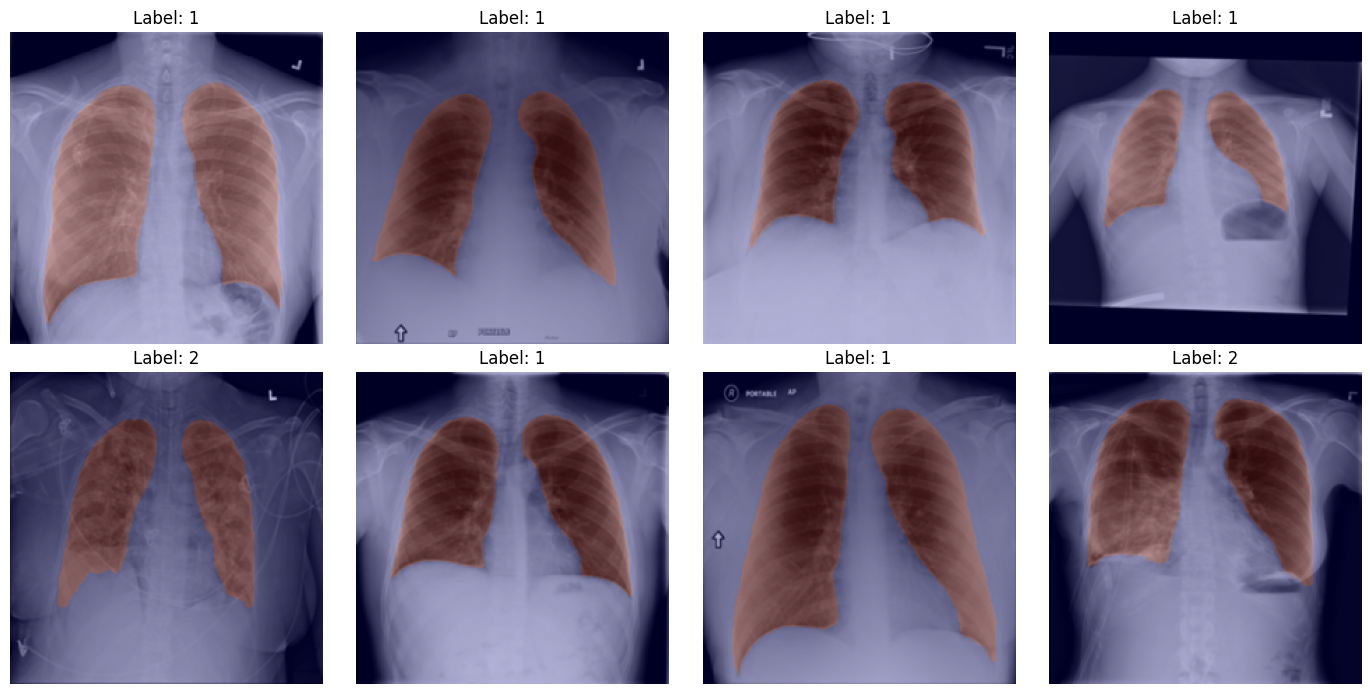

In [22]:
import torch
from torch.utils.data import Dataset, DataLoader

class MaskedCXRDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_AREA)
        mask = cv2.resize(
            (mask > 127).astype(np.uint8),
            (224, 224),
            interpolation=cv2.INTER_NEAREST,
        )

        image = np.stack([image, image, image], axis=-1)  # 3-channel for ImageNet-pretrained models
        image = torch.tensor(image, dtype=torch.float32) / 255.0
        image = image.permute(2, 0, 1)

        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(int(row["class_id"]), dtype=torch.long)

        return image, mask, label


train_df = manifest_with_split[manifest_with_split["split"] == "train"]
train_dataset = MaskedCXRDataset(train_df)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)

images, masks, labels = next(iter(train_loader))
print("Images:", images.shape)
print("Masks :", masks.shape)
print("Labels:", labels.shape)

# Visual check: images and masks should still line up after the full pipeline
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(8):
    ax = axes.flat[i]
    ax.imshow(images[i][0], cmap="gray")
    ax.imshow(masks[i][0], cmap="jet", alpha=0.3)
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [23]:
import shutil

shutil.make_archive("/kaggle/working/m5_lung_segmentation", "zip", "/kaggle/working/m5_lung_segmentation")

'/kaggle/working/m5_lung_segmentation.zip'

In [24]:
import os
for f in os.listdir("/kaggle/working"):
    print(f)

Chest-X-ray-Disease-Detection
dataset_manifest_v1.csv
m5_lung_segmentation
mask_quality_report.csv
m5_lung_segmentation.zip
__notebook__.ipynb


In [25]:
%cd /kaggle/working/Chest-X-ray-Disease-Detection

!git config user.email "dinukakeshara55@gmail.com"
!git config user.name "Dinuka"

!git checkout -b m5-lung-mask-verification

/kaggle/working/Chest-X-ray-Disease-Detection
Switched to a new branch 'm5-lung-mask-verification'


In [26]:
import shutil, os

os.makedirs("artifacts/segmentation", exist_ok=True)
shutil.copy("/kaggle/working/dataset_manifest_v1.csv", "artifacts/segmentation/")
shutil.copy("/kaggle/working/mask_quality_report.csv", "artifacts/segmentation/")
# copy your notebook here too if it's saved somewhere accessible, or add it after downloading locally

'artifacts/segmentation/mask_quality_report.csv'

In [27]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
GITHUB_TOKEN = user_secrets.get_secret("GITHUB_TOKEN")  # the label you typed above, not the token value

In [28]:
!git push https://{GITHUB_TOKEN}@github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git m5-lung-mask-verification

To https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git
 ! [rejected]        m5-lung-mask-verification -> m5-lung-mask-verification (non-fast-forward)
error: failed to push some refs to 'https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [29]:
!git status

On branch m5-lung-mask-verification
nothing to commit, working tree clean


In [30]:
!git add artifacts/segmentation/
!git status

The following paths are ignored by one of your .gitignore files:
artifacts/segmentation
hint: Use -f if you really want to add them.
hint: Turn this message off by running
hint: "git config advice.addIgnoredFile false"
On branch m5-lung-mask-verification
nothing to commit, working tree clean


In [31]:
!git commit -m "M5: verify and preprocess primary dataset's supplied lung masks (P01-P05)"

On branch m5-lung-mask-verification
nothing to commit, working tree clean


In [32]:
!git push https://{GITHUB_TOKEN}@github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git m5-lung-mask-verification

To https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git
 ! [rejected]        m5-lung-mask-verification -> m5-lung-mask-verification (non-fast-forward)
error: failed to push some refs to 'https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [33]:
with open(".gitignore", "a") as f:
    f.write("!artifacts/segmentation/\n")

!cat .gitignore  # confirm the line was added at the end

# Secrets / environment
.env
.env.*

# Experiment tracking
wandb/

# Model checkpoints and generated experiment artifacts
# (tracked via W&B artifacts / local disk, not Git)
*.pth
*.pt
artifacts/*
!artifacts/.gitkeep
!artifacts/DenseNet121-HPO/
artifacts/DenseNet121-HPO/*
!artifacts/DenseNet121-HPO/.gitkeep

# Exceptions: reproducibility inputs/small result summaries that
# docs/experiment_policy.md requires to be committed (the split manifest;
# T18's JSON/CSV/figure artifacts) -- unlike bulk checkpoints, which the
# *.pt / *.pth rules above still exclude even inside these directories.
!artifacts/splits/
!artifacts/T18_lung_attention/
!artifacts/densenet121_auxseg/
!artifacts/efficientnet_b0/
!artifacts/efficiency_results.csv

# Kaggle-generated notebook metadata and rendered output images
/artifacts/**/__huggingface_repos__.json
/artifacts/**/__results___files/

# Python
__pycache__/
*.pyc
.ipynb_checkpoints/
.venv/
venv/
*.egg-info/

# OS
.DS_Store

# Data (never commit dataset file

In [34]:
!git add .gitignore artifacts/segmentation/
!git status

On branch m5-lung-mask-verification
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   .gitignore
	new file:   artifacts/segmentation/dataset_manifest_v1.csv
	new file:   artifacts/segmentation/mask_quality_report.csv



In [35]:
!git commit -m "M5: verify and preprocess primary dataset's lung masks (P01-P05); add artifacts/segmentation/ to .gitignore exceptions, matching existing pattern"

[m5-lung-mask-verification eddbf61] M5: verify and preprocess primary dataset's lung masks (P01-P05); add artifacts/segmentation/ to .gitignore exceptions, matching existing pattern
 3 files changed, 42333 insertions(+)
 create mode 100644 artifacts/segmentation/dataset_manifest_v1.csv
 create mode 100644 artifacts/segmentation/mask_quality_report.csv


In [36]:
!git push https://{GITHUB_TOKEN}@github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git m5-lung-mask-verification

To https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git
 ! [rejected]        m5-lung-mask-verification -> m5-lung-mask-verification (non-fast-forward)
error: failed to push some refs to 'https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [37]:
!cp /kaggle/working/__notebook_source__.ipynb notebooks/M5_lung_masking_kaggle.ipynb
!git add notebooks/M5_lung_masking_kaggle.ipynb
!git commit -m "M5: add Kaggle lung-masking notebook"
!git push https://{GITHUB_TOKEN}@github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git m5-lung-mask-verification

cp: cannot stat '/kaggle/working/__notebook_source__.ipynb': No such file or directory
fatal: pathspec 'notebooks/M5_lung_masking_kaggle.ipynb' did not match any files
On branch m5-lung-mask-verification
nothing to commit, working tree clean
To https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git
 ! [rejected]        m5-lung-mask-verification -> m5-lung-mask-verification (non-fast-forward)
error: failed to push some refs to 'https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [38]:
!cp /kaggle/working/.virtual_documents/__notebook_source__.ipynb notebooks/M5_lung_masking_kaggle.ipynb
!git add notebooks/M5_lung_masking_kaggle.ipynb
!git commit -m "M5: add Kaggle lung-masking notebook"
!git push https://{GITHUB_TOKEN}@github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git m5-lung-mask-verification

cp: cannot stat '/kaggle/working/.virtual_documents/__notebook_source__.ipynb': No such file or directory
fatal: pathspec 'notebooks/M5_lung_masking_kaggle.ipynb' did not match any files
On branch m5-lung-mask-verification
nothing to commit, working tree clean
To https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git
 ! [rejected]        m5-lung-mask-verification -> m5-lung-mask-verification (non-fast-forward)
error: failed to push some refs to 'https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.
